In [10]:
# --- SOLUCIÓN DE APRENDIZAJE AUTOMÁTICO ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
import xgboost as xgb
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                            f1_score, roc_auc_score, confusion_matrix,
                            precision_recall_curve, make_scorer)

from imblearn.pipeline import Pipeline as ImbPipeline

import joblib
import warnings
warnings.filterwarnings('ignore')

In [11]:
# ======================
#  CARGA DE DATOS
# ======================
print("Cargando datos...")
df = pd.read_csv('data.csv')

# Convertir variable target
df['OBJ'] = df['OBJ'].map({'NO': 0, 'SI': 1})

# Manejo de valores faltantes
print("\nHManejo de valores nulos...")
df.fillna(df.median(numeric_only=True), inplace=True)

Cargando datos...

HManejo de valores nulos...


In [12]:
# ======================
#  PREPROCESAMIENTO DE DATOS
# ======================

# Generación eficiente de características cruzadas y flags  binarizadas mediante preasignación
cross_features = {}
binarized_flags = {}

for i in range(1, 31):
    for j in range(i + 1, 31):
        cross_features[f'V{i}_x_V{j}'] = df[f'V{i}'] * df[f'V{j}']
    binarized_flags[f'V{i}_gt_mean'] = (df[f'V{i}'] > df[f'V{i}'].mean()).astype(int)

# Concatenar todas las nuevas características a la vez
df = pd.concat([df, pd.DataFrame(cross_features), pd.DataFrame(binarized_flags)], axis=1)
df = df.copy()  # Desfragmentar para evitar futuras advertencias

# Características target
y = df['OBJ']
X = df.drop(columns=['OBJ'])

# Separación Train-test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [ ]:
# ======================
#  PIPELINES DE MODELOS
# ======================

# Pipeline RF
pipe_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

# Calcula el scale_pos_weight para XGBoost. 
# Esta es la forma más eficiente de gestionar el desequilibrio de clases y es el equivalente directo de 'class_weight=balanced'.
# La fórmula es: count(negative_class) / count(positive_class)
neg_count = y_train.value_counts()[0]
pos_count = y_train.value_counts()[1]
scale_pos_weight_value = neg_count / pos_count

print(f"Dimensión calculada de scale_pos_weight para XGBoost: {scale_pos_weight_value:.2f}")

# XGBoost pipeline
pipe_xgb = ImbPipeline(steps=[
    ('scaler', StandardScaler()),
    ('clf', xgb.XGBClassifier(
        random_state=42,
        scale_pos_weight=scale_pos_weight_value, # Utilizar el weight calculado
        objective='binary:logistic',
        eval_metric='logloss',
        use_label_encoder=False # Para suprimir una posible advertencia
    ))
])

Dimensión calculada de scale_pos_weight para XGBoost: 2.82


In [14]:
# ======================
#  HIPERPARÁMETROS
# ======================

# Grid RF
param_grid_rf = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [5, 10],
    'clf__min_samples_split': [2, 5]
}

# Grid XGB
# Se centra en los parámetros más impactantes para mantener bajo el tiempo de entrenamiento.
param_grid_xgb = {
    'clf__n_estimators': [100, 200],         # ¿Cuántos árboles construir?
    'clf__max_depth': [3, 5, 7],            # Controla la complejidad del árbol. Comienza con valores más pequeños.
    'clf__learning_rate': [0.05, 0.1, 0.2],  # Qué rápido aprende el modelo.
    'clf__subsample': [0.7, 0.8],           # Fracción de muestras utilizadas para cada árbol (evita sobreajuste).
    'clf__colsample_bytree': [0.7, 0.8]     # Fracción de características utilizadas para cada árbol.
}

In [15]:
# ======================
#  ENTRENAMIENTO DE MODELOS
# ======================
models = {
    'Random_Forest': (pipe_rf, param_grid_rf),
    'XGBoost': (pipe_xgb, param_grid_xgb)
}

best_models = {}
results = []

print("\n=== ENTRENAMIENTO DE MODELOS ===")
for name, (pipe, params) in models.items():
    print(f"\n{'='*40}")
    print(f"Entrenando {name}...")
    print(f"{'='*40}")

    try:
        # Grid Search con manejo de errores
        gs = GridSearchCV(
            estimator=pipe,
            param_grid=params,
            scoring='f1',
            cv=5,
            n_jobs=-1,
            verbose=2,
            error_score='raise'  # Obtención de errores detallados
        )
        gs.fit(X_train, y_train)

        # Almacenar el mejor modelo
        best_models[name] = gs.best_estimator_

        # Predicciones
        y_pred = gs.predict(X_test)
        y_proba = gs.predict_proba(X_test)[:, 1]

        # Métricas
        metrics = {
            'Model': name,
            'Best Params': gs.best_params_,
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred, zero_division=0),
            'Recall': recall_score(y_test, y_pred),
            'F1-Score': f1_score(y_test, y_pred),
            'ROC-AUC': roc_auc_score(y_test, y_proba)
        }
        results.append(metrics)

        print(f"\n{name} Mejores Parametros: {gs.best_params_}")
        print(f"Test ROC-AUC: {metrics['ROC-AUC']:.4f}")
        print(f"Test Recall: {metrics['Recall']:.4f}")

    except Exception as e:
        print(f"\nERROR in {name}: {str(e)}")
        print("Probando la configuración de respaldo...")

        # Fallback to default model without grid search
        try:
            pipe.set_params(**{k.split('__')[1]: v for k, v in params[0].items()} if isinstance(params, list) else {k.split('__')[1]: v for k, v in params.items()})
            pipe.fit(X_train, y_train)

            y_pred = pipe.predict(X_test)
            y_proba = pipe.predict_proba(X_test)[:, 1]

            metrics = {
                'Model': name + '_Fallback',
                'Best Params': 'Default',
                'Accuracy': accuracy_score(y_test, y_pred),
                'Precision': precision_score(y_test, y_pred, zero_division=0),
                'Recall': recall_score(y_test, y_pred),
                'F1-Score': f1_score(y_test, y_pred),
                'ROC-AUC': roc_auc_score(y_test, y_proba)
            }
            results.append(metrics)

            print(f"Retorno al modelo {name} Rendimiento:")
            print(f"Test ROC-AUC: {metrics['ROC-AUC']:.4f}")

        except Exception as fallback_e:
            print(f"Retorno fallido: {str(fallback_e)}")
            continue


=== ENTRENAMIENTO DE MODELOS ===

Entrenando Random_Forest...
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Random_Forest Mejores Parametros: {'clf__max_depth': 5, 'clf__min_samples_split': 2, 'clf__n_estimators': 100}
Test ROC-AUC: 0.6207
Test Recall: 0.5134

Entrenando XGBoost...
Fitting 5 folds for each of 72 candidates, totalling 360 fits

XGBoost Mejores Parametros: {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__n_estimators': 100, 'clf__subsample': 0.8}
Test ROC-AUC: 0.6306
Test Recall: 0.5687



=== COMPARACIÓN DE MODELOS ===
           Model                                        Best Params  Accuracy  \
1        XGBoost  {'clf__colsample_bytree': 0.8, 'clf__learning_...     0.614   
0  Random_Forest  {'clf__max_depth': 5, 'clf__min_samples_split'...     0.639   

   Precision    Recall  F1-Score   ROC-AUC  
1   0.353081  0.568702  0.435673  0.630611  
0   0.365489  0.513359  0.426984  0.620709  

Mejor Modelo: XGBoost (ROC-AUC: 0.6306)

Threshold óptimo: 0.4106 (default=0.5)

Rendimiento optimizado:
Accuracy: 0.4660
Precision: 0.3038
Recall: 0.8034
F1-Score: 0.4408


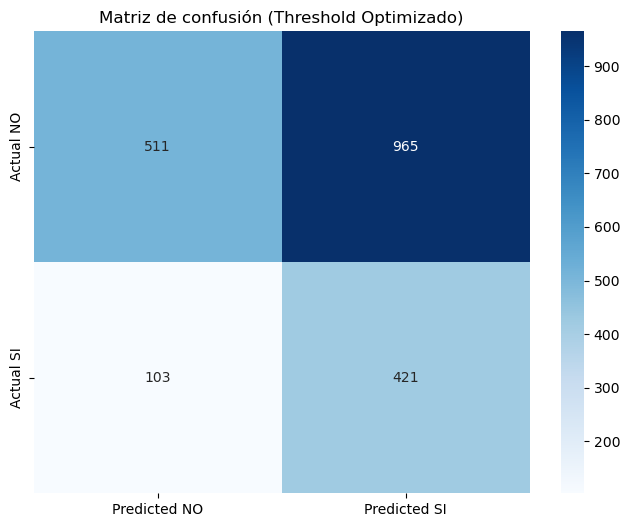


Se guardó el mejor modelo como 'best_model.pkl'


In [16]:
# ======================
#  ANÁLISIS DE RESULTADOS
# ======================
if results:
    results_df = pd.DataFrame(results)
    print("\n=== COMPARACIÓN DE MODELOS ===")
    print(results_df.sort_values('ROC-AUC', ascending=False))

    # Selección del mejor modelo
    best_model_name = results_df.loc[results_df['ROC-AUC'].idxmax(), 'Model']
    best_model = best_models[best_model_name]
    print(f"\nMejor Modelo: {best_model_name} (ROC-AUC: {results_df['ROC-AUC'].max():.4f})")

    # Optimización de threshold
    y_proba = best_model.predict_proba(X_test)[:, 1]
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-6)
    best_threshold = thresholds[np.argmax(f1_scores)]

    print(f"\nThreshold óptimo: {best_threshold:.4f} (default=0.5)")
    y_pred_opt = (y_proba >= best_threshold).astype(int)

    print("\nRendimiento optimizado:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred_opt):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred_opt, zero_division=0):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred_opt):.4f}")
    print(f"F1-Score: {f1_score(y_test, y_pred_opt):.4f}")

    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred_opt)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted NO', 'Predicted SI'],
                yticklabels=['Actual NO', 'Actual SI'])
    plt.title('Matriz de confusión (Threshold Optimizado)')
    plt.savefig('confusion_matrix.png')
    plt.show()

    # Guardar el mejor modelo
    joblib.dump(best_model, 'best_model.pkl')
    print("\nSe guardó el mejor modelo como 'best_model.pkl'")
else:
    print("\nNingún modelo se entrenó correctamente")